
# 🏁 iRacing Telemetry → Coaching Pipeline (End-to-End)

This notebook builds a **complete, reproducible pipeline** to turn iRacing telemetry into **sector-level coaching**.

You will:
1. **Load** raw telemetry (from `.ibt` via `irsdk` or from a pre-saved CSV).
2. **Clean & normalize** the signals; convert units.
3. **Align laps** by distance percentage and visualize **time loss vs reference**.
4. **Split the lap into sectors**, compute sector statistics and deltas.
5. Build a **robust sector reference** (median of the top K% fastest laps).
6. Engineer features, **train a regressor** (LightGBM fallback to GradientBoosting), and report cross-validated metrics.
7. Apply a **per-sector residual bias correction** and re-evaluate metrics.
8. Generate **rule-based coaching** in milliseconds (ms).
9. (Optional) Call a **local LLM via Ollama** to produce **professional English coaching** using a structured JSON context.

> **Note:** All visuals use Matplotlib. No external internet is required. If `irsdk` is unavailable, you can work from CSV.



## 0. Environment checks & configuration

Fill the paths and flags below. If you don't have `.ibt` or `irsdk`, set `USE_IBT=False` and point to a CSV created earlier.


In [1]:

# --- Imports
import os
from pathlib import Path
from typing import Dict, List, Tuple, Any, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ML / Explainability (LightGBM optional)
try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
except Exception:
    LGB_AVAILABLE = False

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.inspection import permutation_importance

# Optional SHAP (if available)
try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False

# Optional irsdk (for .ibt)
try:
    import irsdk
    IRSDK_AVAILABLE = True
except Exception:
    IRSDK_AVAILABLE = False

print(f"LightGBM available: {LGB_AVAILABLE}")
print(f"SHAP available    : {SHAP_AVAILABLE}")
print(f"irsdk available   : {IRSDK_AVAILABLE}")

# --- Paths & Parameters
USE_IBT = True  # set True to read a .ibt with irsdk if available

# If USE_IBT=True, set your .ibt path:
ibt_file = Path("data/mx5 mx52016_charlotte 2018 2019 roval 2025-08-02 12-13-03.ibt")  # <--- change me if needed

# If using CSV, set here (the notebook can also create it from IBT):
csv_path = Path("telemetry_data.csv")  # <--- change if you already have a CSV

# Laps to visualize in the "quick overlay" plots (only visualization; robust pipeline auto-selects reference)
laps_to_plot = [2, 3, 4]

# Core pipeline settings
N_SECTORS = 4               # number of sectors to split the track
BASE_GRID_LEN = 1000
TOPK_PERCENT = 0.30          # robust sector reference: median of fastest top K%
PACE_THRESHOLD_MS = 3000.0   # drop laps whose sum of positive sector losses > 2s
CLIP_MS = 1500.0             # clip training target (ms)
SEQ_LEN = 128                # per-sector resampling for stability
SEED = 42

# Output directory
OUT_DIR = Path("iracing_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)


c:\Users\to_fi\anaconda3\envs\irsdk\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LightGBM available: True
SHAP available    : True
irsdk available   : True



## 1. Data loading

Two options:

- **From `.ibt` via `irsdk`** (preferred for raw sessions).
- **From CSV** (if you already exported or `irsdk` is not available).

The notebook will try what you configured above.


In [14]:

def load_from_ibt(ibt_path: Path) -> pd.DataFrame:
    if not IRSDK_AVAILABLE:
        raise RuntimeError("irsdk is not available in this environment.")
    if not ibt_path.exists():
        raise FileNotFoundError(f".ibt file not found: {ibt_path}")
    ibt = irsdk.IBT()
    try:
        ibt.open(str(ibt_path))
        channels = ['SessionTime','Lap','Speed','RPM','Throttle','Brake','LapDistPct','Lat','Lon','SteeringWheelAngle','Gear']
        data = {ch: ibt.get_all(ch) for ch in channels}
    finally:
        ibt.close()
    df = pd.DataFrame(data)
    return df

def basic_clean_and_units(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)
    if "Speed_KPH" not in df.columns and "Speed" in df.columns:
        df["Speed_KPH"] = df["Speed"] * 3.6
    if "Throttle_Pct" not in df.columns and "Throttle" in df.columns:
        df["Throttle_Pct"] = df["Throttle"] * 100.0
    if "Brake_Pct" not in df.columns and "Brake" in df.columns:
        df["Brake_Pct"] = df["Brake"] * 100.0
    return df

# --- Execute loading
if USE_IBT:
    print(f"Loading IBT: {ibt_file}")
    raw_df = load_from_ibt(ibt_file)
    df = basic_clean_and_units(raw_df)
    # Persist CSV for later reuse
    df.to_csv(csv_path, index=False)
    print(f"Saved CSV: {csv_path}")
else:
    if not csv_path.exists():
        raise FileNotFoundError(f"CSV not found: {csv_path} — Set USE_IBT=True or create the CSV first.")
    df = pd.read_csv(csv_path)
    df = basic_clean_and_units(df)
    print(f"Loaded CSV: {csv_path}  |  rows={len(df)}")

df.head()


Loading IBT: data\mx5 mx52016_charlotte 2018 2019 roval 2025-08-02 12-13-03.ibt
Saved CSV: telemetry_data.csv


,SessionTime,Lap,Speed,RPM,Throttle,Brake,LapDistPct,Lat,Lon,SteeringWheelAngle,Gear,Speed_KPH,Throttle_Pct,Brake_Pct
0,39.533333,0,0.000000,300.0,0.0,1.0,0.000000,0.000000,0.000000,0.037275,0,0.000000,0.0,100.0
1,39.550000,0,0.006040,300.0,0.0,1.0,0.067466,35.350725,-80.685287,0.037275,0,0.021742,0.0,100.0
2,39.566666,0,0.004650,300.0,0.0,1.0,0.067466,35.350725,-80.685287,0.037275,0,0.016741,0.0,100.0
3,39.583333,0,0.015756,300.0,0.0,1.0,0.067466,35.350725,-80.685287,0.037275,0,0.056723,0.0,100.0
4,39.600000,0,0.030305,300.0,0.0,1.0,0.067466,35.350725,-80.685287,0.037275,0,0.109096,0.0,100.0



## 2. Utility functions

Lap duration, validity screening, and lap alignment by `LapDistPct`.


In [15]:

def lap_time_seconds(g: pd.DataFrame) -> float:
    gs = g.sort_values("SessionTime")
    return float(gs["SessionTime"].iloc[-1] - gs["SessionTime"].iloc[0])

def build_lap_validity_table(
    df: pd.DataFrame,
    manual_invalid: Optional[set] = None,
    low_speed_kph: float = 10.0,
    min_max_speed_kph: float = 60.0,
    min_completed_pct: float = 0.98,
) -> pd.DataFrame:
    manual_invalid = manual_invalid or set()
    rows = []
    for lap, g in df.groupby("Lap", sort=True):
        gs = g.sort_values("SessionTime").copy()
        rows.append({
            "Lap": int(lap),
            "LapTime_s": lap_time_seconds(gs),
            "CompletedPct": float(gs["LapDistPct"].max()),
            "FracLowSpeed": float((gs["Speed_KPH"] < low_speed_kph).mean()),
            "MaxSpeed_kph": float(gs["Speed_KPH"].max()),
        })
    lap_df = pd.DataFrame(rows).sort_values("Lap").reset_index(drop=True)
    valid = (
        (lap_df["CompletedPct"] >= min_completed_pct) &
        (~lap_df["Lap"].isin(manual_invalid)) &
        (lap_df["FracLowSpeed"] <= 0.25) &
        (lap_df["MaxSpeed_kph"] >= min_max_speed_kph)
    )
    lap_df["Valid"] = valid

    # Tukey outlier filter on valid lap times
    if lap_df["Valid"].sum() >= 5:
        q1, q3 = lap_df.loc[lap_df["Valid"], "LapTime_s"].quantile([0.25, 0.75])
        iqr = float(q3 - q1); hi = float(q3 + 1.5 * iqr); lo = max(0.0, float(q1 - 1.5 * iqr))
        lap_df.loc[:, "Valid"] &= lap_df["LapTime_s"].between(lo, hi)
    return lap_df

def align_lap_by_dist(g: pd.DataFrame, grid: np.ndarray) -> Dict[str, np.ndarray]:
    g = g.sort_values("LapDistPct").drop_duplicates(subset=["LapDistPct"], keep="first")
    if g.empty: return {}
    t_rel = g["SessionTime"] - g["SessionTime"].iloc[0]
    x = g["LapDistPct"].to_numpy()
    if len(x) < 2 or np.allclose(x.max() - x.min(), 0): return {}
    def interp(y: np.ndarray) -> np.ndarray:
        return np.interp(grid, x, y)
    out = {
        "t_rel": interp(t_rel.to_numpy()),
        "speed": interp(g["Speed_KPH"].to_numpy()),
        "throttle": interp(g["Throttle_Pct"].to_numpy()),
        "brake": interp(g["Brake_Pct"].to_numpy()),
    }
    if "RPM" in g.columns:
        out["rpm"] = interp(g["RPM"].to_numpy())
    return out



## 3. Lap validity & reference selection

We mark laps as valid and pick a **reference lap** (fastest among valid). We'll also pick a **target lap** to compare.


In [28]:
def format_laptime(seconds: float) -> str:
    """Converte um tempo em segundos para o formato de string MM:SS.ms."""
    if pd.isna(seconds):
        return "N/A"
    # Calcula os minutos
    minutes = int(seconds // 60)
    # Calcula os segundos restantes com milissegundos
    remaining_seconds = seconds % 60
    # Retorna a string formatada, garantindo dois dígitos para os minutos
    # e preenchimento com zero para os segundos (ex: 01:05.123)
    return f"{minutes:02d}:{remaining_seconds:06.3f}"


INVALID_LAPS = set()  # add warm-up, pit-in/out laps if needed
TARGET_LAP_TO_ANALYZE = 10

# Assumimos que a função build_lap_validity_table() já existe
# e retorna um DataFrame com a coluna 'LapTime_s'
lap_df = build_lap_validity_table(df, manual_invalid=INVALID_LAPS)

# 1. Adicionamos uma nova coluna ao DataFrame com o tempo formatado
lap_df['LapTime_Formatted'] = lap_df['LapTime_s'].apply(format_laptime)

# Exibimos o DataFrame com a nova coluna para melhor visualização
display(lap_df[['Lap', 'Valid', 'LapTime_s', 'LapTime_Formatted']])

valid_laps = lap_df[lap_df["Valid"]]["Lap"].tolist()
if not valid_laps:
    raise RuntimeError("No valid laps found.")

ref_row = lap_df[lap_df["Valid"]].sort_values("LapTime_s").iloc[0]
ref_lap = int(ref_row["Lap"])
candidates = [l for l in valid_laps if l != ref_lap]

#   target_lap = int(max(candidates)) if candidates else ref_lap #target lap is the slowest valid lap
target_lap = TARGET_LAP_TO_ANALYZE
target_row = lap_df[lap_df['Lap'] == target_lap].iloc[0]

print(f"Reference lap: {ref_lap}  ({format_laptime(ref_row['LapTime_s'])})")
# A linha abaixo foi atualizada para incluir o tempo da 'target_lap'
print(f"Target lap   : {target_lap}  ({format_laptime(target_row['LapTime_s'])})")


,Lap,Valid,LapTime_s,LapTime_Formatted
0,0,False,1349.466667,22:29.467
1,1,False,180.633333,03:00.633
2,2,True,96.566667,01:36.567
3,3,False,41.516667,00:41.517
4,4,True,96.966667,01:36.967
5,5,True,97.066667,01:37.067
6,6,True,98.133333,01:38.133
7,7,False,293.216667,04:53.217
8,8,True,97.266667,01:37.267
9,9,True,95.833333,01:35.833


Reference lap: 9  (01:35.833)
Target lap   : 10  (01:35.967)



## 4. Lap alignment & quick plots

We align laps by **LapDistPct** to compare signals and compute **time loss vs reference**.


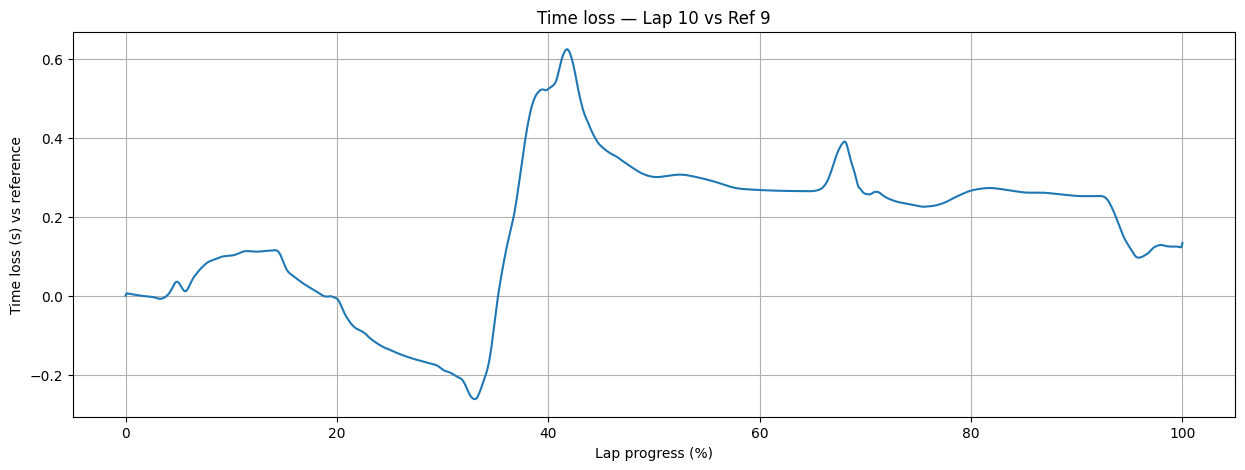

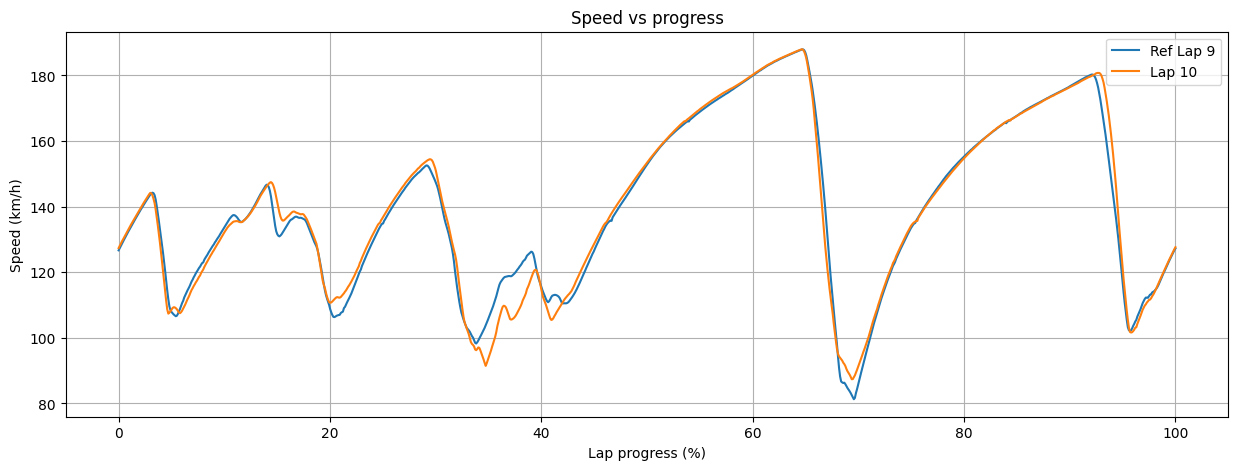

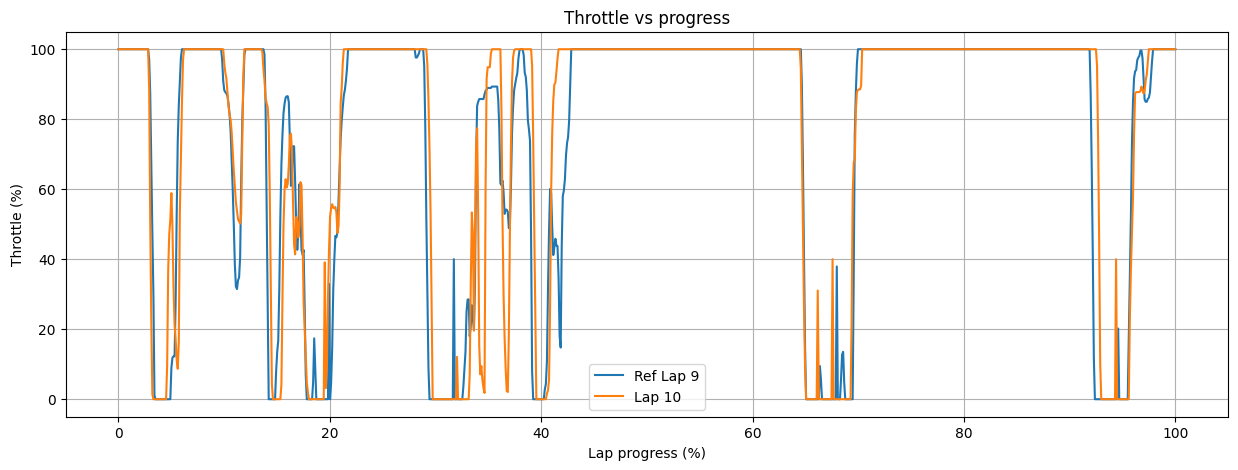

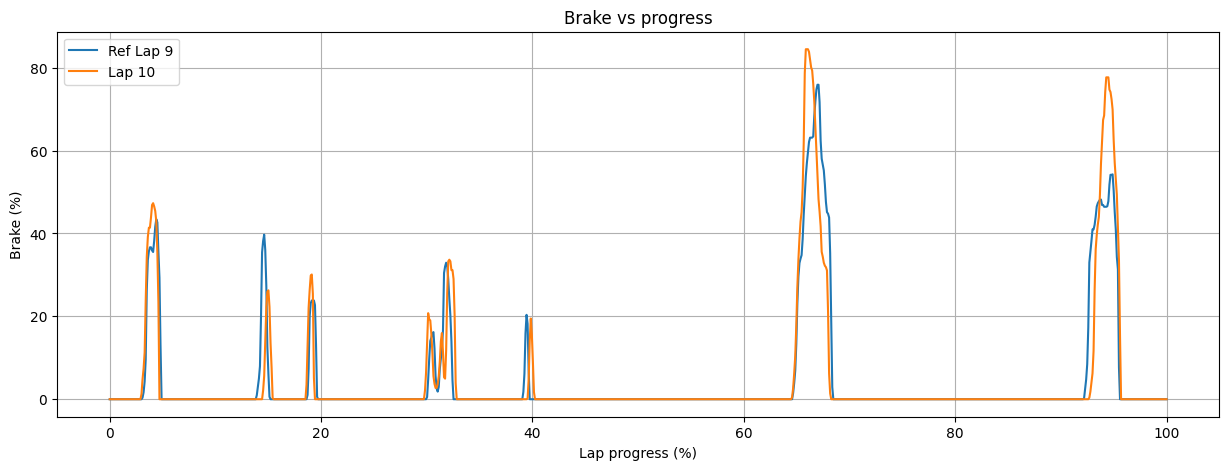

In [31]:

grid = np.linspace(0.0, 1.0, BASE_GRID_LEN)

g_ref = df[df["Lap"] == ref_lap]
g_tgt = df[df["Lap"] == target_lap]

ref_interp = align_lap_by_dist(g_ref, grid)
tgt_interp = align_lap_by_dist(g_tgt, grid)

# Time-loss curve (target vs reference)
time_loss = tgt_interp["t_rel"] - ref_interp["t_rel"]

plt.figure(figsize=(15, 5))
plt.plot(grid*100.0, time_loss)
plt.xlabel("Lap progress (%)")
plt.ylabel("Time loss (s) vs reference")
plt.title(f"Time loss — Lap {target_lap} vs Ref {ref_lap}")
plt.grid(True)
plt.show()

# Overlay speed, throttle, brake
def quick_plot(y1, y2, label, ylab):
    plt.figure(figsize=(15, 5))
    plt.plot(grid*100.0, y1, label=f"Ref Lap {ref_lap}")
    plt.plot(grid*100.0, y2, label=f"Lap {target_lap}")
    plt.xlabel("Lap progress (%)")
    plt.ylabel(ylab)
    plt.title(f"{label} vs progress")
    plt.legend()
    plt.grid(True)
    plt.show()

quick_plot(ref_interp["speed"],    tgt_interp["speed"],    "Speed",    "Speed (km/h)")
quick_plot(ref_interp["throttle"], tgt_interp["throttle"], "Throttle", "Throttle (%)")
quick_plot(ref_interp["brake"],    tgt_interp["brake"],    "Brake",    "Brake (%)")



## 5. Sectorization and per-sector analysis

In the Charlotte track, we split the lap into **4 equal-length sectors** and compute per-sector **time, deltas, and simple signal differences**.


In [32]:

def sector_slices(n_points: int, n_sectors: int) -> List[slice]:
    edges = np.linspace(0, n_points - 1, n_sectors + 1).astype(int)
    out = []
    for i in range(n_sectors):
        a, b = edges[i], edges[i+1]
        if b <= a: b = a + 1
        out.append(slice(a, b + 1))
    return out

def sector_analysis(ref_interp: Dict[str, np.ndarray],
                    tgt_interp: Dict[str, np.ndarray],
                    n_sectors: int) -> pd.DataFrame:
    n = len(ref_interp["t_rel"])
    slices = sector_slices(n, n_sectors)
    rows = []
    for i, sl_ in enumerate(slices, start=1):
        a, b = sl_.start, sl_.stop - 1
        ref_sec_time = float(ref_interp["t_rel"][b] - ref_interp["t_rel"][a])
        tgt_sec_time = float(tgt_interp["t_rel"][b] - tgt_interp["t_rel"][a])
        sl = slice(a, b + 1)
        rows.append({
            "Sector": i,
            "Start_%": round(100 * a / (n-1), 1),
            "End_%":   round(100 * b / (n-1), 1),
            "RefTime_s": ref_sec_time,
            "TargetTime_s": tgt_sec_time,
            "DeltaTime_s": float(tgt_sec_time - ref_sec_time),
            "MeanSpeedDiff_kph": float(np.nanmean(tgt_interp["speed"][sl] - ref_interp["speed"][sl])),
            "MeanThrottleDiff_pct": float(np.nanmean(tgt_interp["throttle"][sl] - ref_interp["throttle"][sl])),
            "MeanBrakeDiff_pct": float(np.nanmean(tgt_interp["brake"][sl] - ref_interp["brake"][sl])),
        })
    return pd.DataFrame(rows)

sectors = sector_analysis(ref_interp, tgt_interp, n_sectors=N_SECTORS)
sectors


,Sector,Start_%,End_%,RefTime_s,TargetTime_s,DeltaTime_s,MeanSpeedDiff_kph,MeanThrottleDiff_pct,MeanBrakeDiff_pct
0,1,0.0,24.9,25.282356,25.146044,-0.136312,0.567656,0.607139,-0.240675
1,2,24.9,49.9,25.940012,26.377319,0.437307,-1.339868,3.343775,0.297849
2,3,49.9,75.0,22.732079,22.658248,-0.073831,0.278218,-0.153754,-0.295658
3,4,75.0,100.0,21.878886,21.785055,-0.093831,0.713790,2.046979,0.519091



## 6. Feature engineering per sector (all valid laps) + robust reference

We compute compact sector-level features for **every valid lap**, and we build a **robust sector reference** as the **median** of the top K% fastest laps.


In [33]:

def sector_edges(n_points: int, n_sectors: int) -> List[Tuple[int,int]]:
    edges = np.linspace(0, n_points-1, n_sectors+1).astype(int)
    out = []
    for i in range(n_sectors):
        a, b = edges[i], edges[i+1]
        if b <= a: b = a+1
        out.append((a, b))
    return out

def resample_idx(n_src: int, n_dst: int) -> np.ndarray:
    return np.linspace(0, n_src-1, n_dst).astype(int)

def sector_features(sec: pd.DataFrame) -> Dict[str, float]:
    arr = {k: sec[k].to_numpy() for k in sec.columns}
    d = {}
    d["time_s"]   = float(arr["t_rel"][-1] - arr["t_rel"][0])
    d["spe_mean"] = float(arr["speed"].mean())
    d["spe_max"]  = float(arr["speed"].max())
    d["spe_min"]  = float(arr["speed"].min())
    d["spe_delta"] = float(arr["speed"][-1] - arr["speed"][0])
    d["thr_mean"] = float(arr["throttle"].mean())
    d["thr_p95"]  = float(np.percentile(arr["throttle"], 95))
    d["thr_on_ratio"] = float((arr["throttle"] > 5).mean())
    d["bra_mean"] = float(arr["brake"].mean())
    d["bra_p95"]  = float(np.percentile(arr["brake"], 95))
    d["bra_on_ratio"] = float((arr["brake"] > 5).mean())
    if "rpm" in sec.columns:
        d["rpm_mean"] = float(arr["rpm"].mean())
        d["rpm_max"]  = float(arr["rpm"].max())
        
     # --- Novas Heurísticas (Básicas) ---
    d["coa_ratio"] = float(((arr["throttle"] < 5) & (arr["brake"] < 5)).mean())
    if "Gear" in arr and len(arr["Gear"]) > 0:
        apex_idx = arr["speed"].argmin()
        d["gear_at_apex"] = int(arr["Gear"][apex_idx])
        
    # --- Novas Heurísticas (Avançadas) ---
    if "SteeringWheelAngle" in arr:
        # 1. Suavidade do Volante
        d["steer_std_dev"] = float(arr["SteeringWheelAngle"].std())
        
        # 2. Trail Braking Ratio (limiar de 20 graus, ajuste se necessário)
        is_turning = np.abs(arr["SteeringWheelAngle"]) > 20 
        is_braking = arr["brake"] > 5
        d["trail_brake_ratio"] = float((is_turning & is_braking).mean())
        
        # 3. Proxy para Subesterço (Understeer)
        peak_steer_index = np.argmax(np.abs(arr["SteeringWheelAngle"]))
        d["peak_steer_pct"] = float(peak_steer_index / len(arr["SteeringWheelAngle"])) if len(arr["SteeringWheelAngle"]) > 0 else 0.0

    # 4. Qualidade da Aceleração
    throttle_trace = arr["throttle"]
    if len(throttle_trace) > 1:
        throttle_derivative = np.diff(throttle_trace, prepend=throttle_trace[0])
        d["thr_attack_rate"] = float(np.max(throttle_derivative))
    else:
        d["thr_attack_rate"] = 0.0
         
        
    return d
    

def build_sector_table_no_ref(df: pd.DataFrame, valid_laps: List[int], n_sectors: int, seq_len: int) -> pd.DataFrame:
    grid = np.linspace(0.0, 1.0, BASE_GRID_LEN)
    rows = []
    for lap in valid_laps:
        interp = align_lap_by_dist(df[df["Lap"]==lap], grid)
        if not interp: continue
        raw = pd.DataFrame(interp)
        edges = sector_edges(len(raw), n_sectors)
        for sid,(a,b) in enumerate(edges, start=1):
            sec = raw.iloc[a:b+1].copy()
            idx = resample_idx(len(sec), seq_len)
            sec = sec.iloc[idx].reset_index(drop=True)
            feats = sector_features(sec)
            feats.update({"lap": int(lap), "sector": int(sid)})
            rows.append(feats)
    return pd.DataFrame(rows)

def build_ref_sector_times_topk(df, valid_laps, n_sectors, base_grid_len=1000, k_percent=0.3):
    grid = np.linspace(0.0, 1.0, base_grid_len)
    laps, times = [], []
    for lap in valid_laps:
        laps.append(lap)
        times.append(lap_time_seconds(df[df["Lap"]==lap]))
    lap_times = pd.DataFrame({"lap": laps, "lap_time": times}).sort_values("lap_time")
    k = max(1, int(len(lap_times) * k_percent))
    top_laps = lap_times.head(k)["lap"].tolist()

    per = []
    for lap in top_laps:
        interp = align_lap_by_dist(df[df["Lap"]==lap], grid)
        if not interp: continue
        edges = sector_edges(len(interp["t_rel"]), n_sectors)
        for sid,(a,b) in enumerate(edges, start=1):
            per.append({"sector": sid, "time_s": float(interp["t_rel"][b]-interp["t_rel"][a])})
    ref = (pd.DataFrame(per)
             .groupby("sector")["time_s"].median()
             .reindex(range(1, n_sectors+1))
             .to_numpy(dtype=np.float32))
    return ref

# --- Bloco 1: Define as voltas de interesse primeiro ---

# Seleciona apenas as voltas válidas com base no tempo total de volta
valid_laps_df = lap_df[lap_df["Valid"]]
if len(valid_laps_df) < 1:
    raise RuntimeError("Nenhuma volta válida encontrada em lap_df para análise.")

# A volta de referência é a mais rápida entre as válidas
ref_row = valid_laps_df.sort_values("LapTime_s").iloc[0]
ref_lap = int(ref_row["Lap"])

# A volta alvo é a que você escolheu na primeira célula (TARGET_LAP_TO_ANALYZE)
# Aqui, usamos a variável global que você definiu na sua célula de configuração.
target_lap = TARGET_LAP_TO_ANALYZE 

# Validação para garantir que a volta escolhida é válida
if target_lap not in valid_laps_df["Lap"].values:
    raise ValueError(f"A volta alvo {target_lap} não é uma volta válida. Voltas válidas são: {valid_laps_df['Lap'].tolist()}")

print("Voltas selecionadas para o processo:")
print(f"Reference Lap: {ref_lap}")
print(f"   Target Lap: {target_lap}")


# --- Bloco 2: Construção da Tabela de Features (com filtro corrigido) ---


valid_laps = lap_df[lap_df["Valid"]]["Lap"].tolist()
feat_table = build_sector_table_no_ref(df, valid_laps, N_SECTORS, SEQ_LEN)
ref_times = build_ref_sector_times_topk(df, valid_laps, N_SECTORS, k_percent=TOPK_PERCENT)
ref_map = {i+1: t for i,t in enumerate(ref_times)}
feat_table["ref_time_sec"] = feat_table["sector"].map(ref_map)

# Target (ms) and pace filter (LÓGICA CORRIGIDA)
feat_table["delta_ms"] = 1000.0 * (feat_table["time_s"] - feat_table["ref_time_sec"])
sum_pos = (feat_table.assign(pos=lambda d: d["delta_ms"].clip(lower=0.0))
                     .groupby("lap")["pos"].sum().reset_index(name="loss_ms"))

# 1. Primeiro, pegamos as voltas que passam no filtro de ritmo
laps_within_pace = sum_pos[sum_pos["loss_ms"] < PACE_THRESHOLD_MS]["lap"].tolist()

# 2. Criamos a lista final, garantindo que a ref_lap e a target_lap estejam presentes
keep_laps_set = set(laps_within_pace)
keep_laps_set.add(ref_lap)
keep_laps_set.add(target_lap)
keep_laps = sorted(list(keep_laps_set))

# 3. A feat_table final é filtrada, mas agora sempre conterá as voltas de interesse
feat_table = feat_table[feat_table["lap"].isin(keep_laps)].reset_index(drop=True)
print(f"\nVoltas mantidas na feat_table (ritmo + alvo): {sorted(set(keep_laps))}  [limiar={PACE_THRESHOLD_MS:.0f} ms]")
feat_table['lap'].value_counts()

Voltas selecionadas para o processo:
Reference Lap: 9
   Target Lap: 10

Voltas mantidas na feat_table (ritmo + alvo): [2, 4, 5, 6, 8, 9, 10]  [limiar=3000 ms]


lap
2     4
4     4
5     4
6     4
8     4
9     4
10    4
Name: count, dtype: int64


## 7. Train a sector-time regressor (delta to reference in ms)

We train a model to predict sector delta (ms) given the per-sector features.  
Cross-validation is **GroupKFold by lap** to avoid information leakage.


X_all: (28, 15) | y: (28,) | features: 15
\n[Features→Regressor]  MAE=0.475±0.126s  RMSE=0.568±0.147s  MAPE=1.95%


,sector,count,mean_delta_ms,mae_ms,ref_time
0,1,7,792.8 ms,700.9 ms,25.214 s
1,2,7,49.2 ms,415.6 ms,26.159 s
2,3,7,46.7 ms,316.0 ms,22.695 s
3,4,7,39.8 ms,346.2 ms,21.832 s


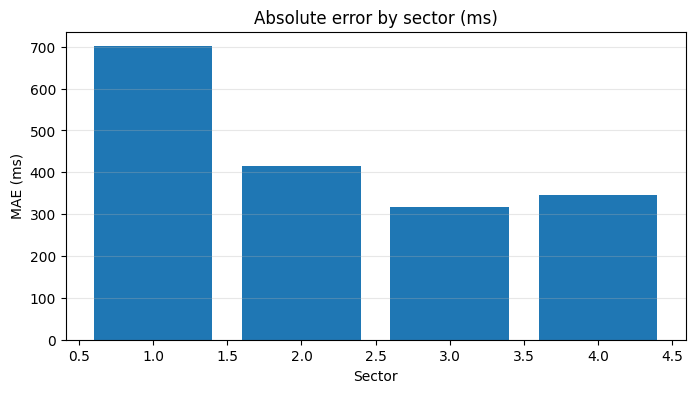

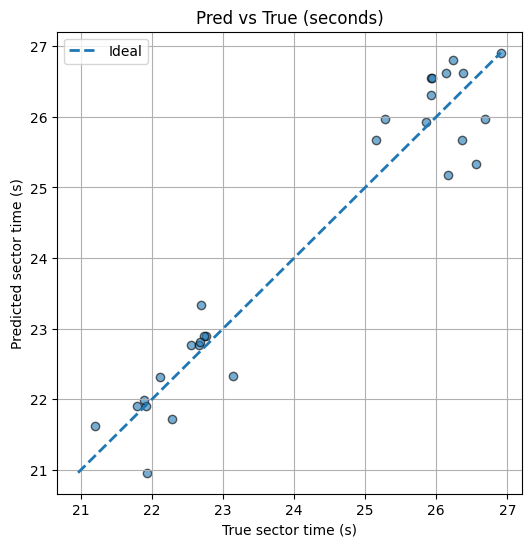

In [34]:

feature_cols = [c for c in feat_table.columns if c not in ("lap","sector","delta_ms","delta_ms_clipped","ref_time_sec")]
X_tab = feat_table[feature_cols].to_numpy().astype(np.float32)
feat_table["delta_ms_clipped"] = np.clip(feat_table["delta_ms"].to_numpy(), -CLIP_MS, CLIP_MS)
y_tab = feat_table["delta_ms_clipped"].to_numpy().astype(np.float32)
groups = feat_table["lap"].to_numpy().astype(int)
sector_ids = feat_table["sector"].to_numpy().astype(int)
ref_times_all = feat_table["ref_time_sec"].to_numpy().astype(np.float32)

print("X_all:", X_tab.shape, "| y:", y_tab.shape, "| features:", len(feature_cols))

gkf = GroupKFold(n_splits=min(5, len(np.unique(groups))))
folds = list(gkf.split(X_tab, y_tab, groups))

mae_s, rmse_s, mape_pct = [], [], []
pred_list_s, true_list_s, sec_list = [], [], []

for i, (tr, va) in enumerate(folds, start=1):
    Xtr, Xva = X_tab[tr], X_tab[va]
    ytr, yva = y_tab[tr], y_tab[va]
    ref_va   = ref_times_all[va]

    if LGB_AVAILABLE:
        dtr = lgb.Dataset(Xtr, label=ytr)
        dva = lgb.Dataset(Xva, label=yva, reference=dtr)
        params = dict(objective="regression", metric="l2", seed=SEED,
                      learning_rate=0.05, num_leaves=31,
                      feature_fraction=0.9, bagging_fraction=0.9, bagging_freq=1,
                      min_data_in_leaf=10, verbosity=-1)
        booster = lgb.train(params, dtr, num_boost_round=1200, valid_sets=[dva])
        pred_ms = booster.predict(Xva, num_iteration=booster.best_iteration)
    else:
        est = GradientBoostingRegressor(
            loss="huber", learning_rate=0.05, n_estimators=1200,
            max_depth=3, subsample=0.85, random_state=SEED
        ).fit(Xtr, ytr)
        pred_ms = est.predict(Xva)

    true_sec = ref_va + (yva    / 1000.0)
    pred_sec = ref_va + (pred_ms / 1000.0)

    mae = float(np.mean(np.abs(pred_sec - true_sec)))
    rmse = float(np.sqrt(np.mean((pred_sec - true_sec)**2)))
    mape = float(np.mean(np.abs((pred_sec - true_sec) / np.maximum(true_sec, 1e-6)))) * 100.0

    mae_s.append(mae); rmse_s.append(rmse); mape_pct.append(mape)
    pred_list_s.append(pred_sec); true_list_s.append(true_sec); sec_list.append(sector_ids[va])

print(f"\\n[Features→Regressor]  MAE={np.mean(mae_s):.3f}±{np.std(mae_s):.3f}s  RMSE={np.mean(rmse_s):.3f}±{np.std(rmse_s):.3f}s  MAPE={np.mean(mape_pct):.2f}%")

pred_sec_all = np.concatenate(pred_list_s)
true_sec_all = np.concatenate(true_list_s)
sec_id_all   = np.concatenate(sec_list)

# Per-sector MAE (ms)
per_sector = []
for s in sorted(feat_table["sector"].unique()):
    mask = (sec_id_all == s)
    ref_s = ref_map[s]
    true_ms = 1000.0 * (true_sec_all[mask] - ref_s)
    pred_ms = 1000.0 * (pred_sec_all[mask] - ref_s)
    per_sector.append({
        "sector": s,
        "count": int(mask.sum()),
        "mean_delta_ms": float(true_ms.mean()),
        "mae_ms": float(np.mean(np.abs(pred_ms - true_ms))),
        "ref_time": ref_s
    })
agg = pd.DataFrame(per_sector).sort_values("sector")
display(agg.style.format({"mean_delta_ms":"{:.1f} ms", "mae_ms":"{:.1f} ms", "ref_time":"{:.3f} s"}))

# Plots
plt.figure(figsize=(8,4))
plt.bar(agg["sector"], agg["mae_ms"])
plt.xlabel("Sector"); plt.ylabel("MAE (ms)")
plt.title("Absolute error by sector (ms)")
plt.grid(axis="y", alpha=0.3); plt.show()

plt.figure(figsize=(6,6))
lims = [min(true_sec_all.min(), pred_sec_all.min()), max(true_sec_all.max(), pred_sec_all.max())]
plt.scatter(true_sec_all, pred_sec_all, alpha=0.6, edgecolors="k")
plt.plot(lims, lims, "--", lw=2, label="Ideal")
plt.xlabel("True sector time (s)"); plt.ylabel("Predicted sector time (s)")
plt.title("Pred vs True (seconds)")
plt.legend(); plt.grid(True); plt.show()



## 8. Sector residual correction and uncertainty (±σ)

We compute **per-sector residuals** (pred − true) in ms, derive mean bias and σ (uncertainty), **correct predictions** by removing the bias, and re-check metrics.


Residual stats by sector:


,sector,mu_ms,sigma_ms,n
0,1,-331.9,758.4,7
1,2,413.5,229.2,7
2,3,87.3,433.4,7
3,4,-96.2,492.7,7


\n== Metrics (after bias correction) ==\nMAE:  0.367 s (367 ms)\nRMSE: 0.476 s (476 ms)\nMAPE: 1.52%


,sector,MAE_ms,count,ref_time
0,1,653.5 ms,7,25.214 s
1,2,177.5 ms,7,26.159 s
2,3,253.6 ms,7,22.695 s
3,4,383.9 ms,7,21.832 s


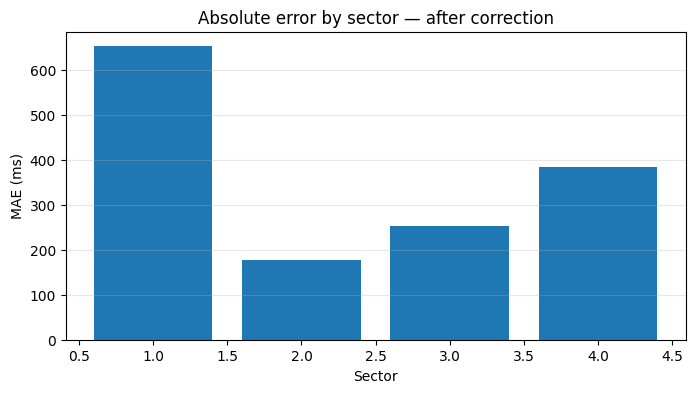

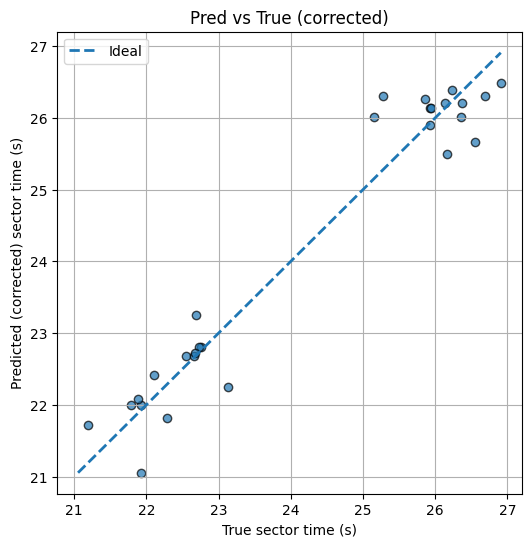

In [35]:

err_ms = 1000.0 * (pred_sec_all - true_sec_all)
df_err = pd.DataFrame({"sector": sec_id_all, "err_ms": err_ms})

stats = (df_err.groupby("sector")
         .agg(mu_ms=("err_ms","mean"), sigma_ms=("err_ms","std"), n=("err_ms","size"))
         .reset_index().sort_values("sector"))

sector_sigma_ms = {int(r["sector"]): float(r["sigma_ms"]) for _, r in stats.iterrows()}
mu_map_ms = {int(r["sector"]): float(r["mu_ms"]) for _, r in stats.iterrows()}

bias_ms = np.array([mu_map_ms[int(s)] for s in sec_id_all], dtype=float)
pred_sec_corr = pred_sec_all - (bias_ms / 1000.0)

mae_s  = float(np.mean(np.abs(pred_sec_corr - true_sec_all)))
rmse_s = float(np.sqrt(np.mean((pred_sec_corr - true_sec_all)**2)))
mape   = float(np.mean(np.abs((pred_sec_corr - true_sec_all) / np.maximum(true_sec_all, 1e-6)))) * 100.0

print("Residual stats by sector:")
display(stats.style.format({"mu_ms":"{:.1f}", "sigma_ms":"{:.1f}", "n":"{:d}"}))

print(f"\\n== Metrics (after bias correction) ==\\nMAE:  {mae_s:.3f} s ({mae_s*1000:.0f} ms)\\nRMSE: {rmse_s:.3f} s ({rmse_s*1000:.0f} ms)\\nMAPE: {mape:.2f}%")

# Overwrite 'pred_sec_all' with corrected values for the next sections
pred_sec_all = pred_sec_corr

# Per-sector corrected MAE
per_sector = []
for s in sorted(np.unique(sec_id_all)):
    m = (sec_id_all == s)
    per_sector.append({
        "sector": int(s),
        "MAE_ms": float(1000.0 * np.mean(np.abs(pred_sec_corr[m] - true_sec_all[m]))),
        "count": int(m.sum()),
        "ref_time": float(ref_map[int(s)]),
    })
agg_corr = pd.DataFrame(per_sector).sort_values("sector")
display(agg_corr.style.format({"MAE_ms":"{:.1f} ms", "ref_time":"{:.3f} s", "count":"{:d}"}))

plt.figure(figsize=(8,4))
plt.bar(agg_corr["sector"], agg_corr["MAE_ms"])
plt.xlabel("Sector"); plt.ylabel("MAE (ms)")
plt.title("Absolute error by sector — after correction")
plt.grid(axis="y", alpha=0.3); plt.show()

plt.figure(figsize=(6,6))
lims = [min(true_sec_all.min(), pred_sec_corr.min()), max(true_sec_all.max(), pred_sec_corr.max())]
plt.scatter(true_sec_all, pred_sec_corr, alpha=0.7, edgecolors="k")
plt.plot(lims, lims, "--", lw=2, label="Ideal")
plt.xlabel("True sector time (s)"); plt.ylabel("Predicted (corrected) sector time (s)")
plt.title("Pred vs True (corrected)")
plt.legend(); plt.grid(True); plt.show()



## 9. Rule-based coaching in milliseconds (ms)

We generate **sector-level recommendations** using simple heuristics from the features.  
We report **potential gains** as 50% of current losses (conservative target).


In [36]:
# ==============================================================================
# 1. FUNÇÕES AUXILIARES PARA ESTA CÉLULA
# ==============================================================================

# (Suas funções `fmt_with_sigma` e `recommend_for_row_ms` que já funcionam bem)
def fmt_with_sigma(delta_ms: float, sector: int) -> str:
    sig = sector_sigma_ms.get(int(sector), np.nan)
    if np.isnan(sig):
        return f"{int(round(delta_ms))} ms"
    return f"{int(round(delta_ms))} ms ± {int(round(sig))} ms"

def recommend_for_row_ms(row, feat_row, ref_feat_row):
    """
    Versão final com um conjunto completo de heurísticas de pilotagem.
    """
    msgs = []
    s = int(row["sector"])
    loss_ms = row["delta_ms"]
    MIN_LOSS_TO_ADVISE_MS = 50.0

    # --- Heurísticas Fundamentais ---
    target_min_speed = feat_row.get("spe_min", 0)
    ref_min_speed = ref_feat_row.get("spe_min", 0)
    if target_min_speed < (ref_min_speed * 0.95) and loss_ms > MIN_LOSS_TO_ADVISE_MS:
        diff_speed = ref_min_speed - target_min_speed
        msgs.append(f"S{s}: velocidade de ápice {diff_speed:.1f} km/h mais lenta. Carregue mais velocidade na entrada da curva (~{int(0.3*loss_ms)} ms).")
    
    target_throttle_ratio = feat_row.get("thr_on_ratio", 1)
    ref_throttle_ratio = ref_feat_row.get("thr_on_ratio", 1)
    if target_throttle_ratio < (ref_throttle_ratio * 0.9) and loss_ms > MIN_LOSS_TO_ADVISE_MS:
        msgs.append(f"S{s}: aceleração mais tardia que a referência. Antecipe a aplicação do acelerador após o ápice para otimizar a tração (~{int(0.3*loss_ms)} ms).")

    # --- Heurísticas de Técnica de Pilotagem ---
    
    # Coasting excessivo
    target_coa_ratio = feat_row.get("coa_ratio", 0)
    ref_coa_ratio = ref_feat_row.get("coa_ratio", 0)
    if target_coa_ratio > (ref_coa_ratio + 0.05) and loss_ms > MIN_LOSS_TO_ADVISE_MS:
        msgs.append(f"S{s}: transição lenta freio-acelerador (coasting). Aplique o acelerador assim que aliviar o freio para manter o carro equilibrado (~{int(0.3*loss_ms)} ms).")

    # Pouco uso de Trail Braking
    target_trail_brake = feat_row.get("trail_brake_ratio", 0)
    ref_trail_brake = ref_feat_row.get("trail_brake_ratio", 0)
    if target_trail_brake < (ref_trail_brake * 0.8) and loss_ms > MIN_LOSS_TO_ADVISE_MS:
        msgs.append(f"S{s}: pouco uso de trail braking. Tente carregar o freio suavemente para dentro da curva para ajudar o carro a girar (~{int(0.2*loss_ms)} ms).")

    # Aceleração muito agressiva na saída
    target_thr_attack = feat_row.get("thr_attack_rate", 0)
    ref_thr_attack = ref_feat_row.get("thr_attack_rate", 0)
    if target_thr_attack > (ref_thr_attack * 1.3) and loss_ms > MIN_LOSS_TO_ADVISE_MS:
        msgs.append(f"S{s}: aplicação de acelerador muito agressiva na saída. Tente ser mais progressivo com o pedal para evitar perda de tração (~{int(0.2*loss_ms)} ms).")
    
    # Indicação de Subesterço (Understeer)
    target_steer_peak_pct = feat_row.get("peak_steer_pct", 0)
    ref_steer_peak_pct = ref_feat_row.get("peak_steer_pct", 0)
    if target_steer_peak_pct > ref_steer_peak_pct and target_steer_peak_pct > 0.6 and loss_ms > MIN_LOSS_TO_ADVISE_MS:
        msgs.append(f"S{s}: pico do volante tardio, sugerindo subesterço. Tente reduzir a velocidade de entrada para ter uma trajetória mais limpa (~{int(0.2*loss_ms)} ms).")
    
    # Marcha errada no ápice
    target_gear_apex = feat_row.get("gear_at_apex", 0)
    ref_gear_apex = ref_feat_row.get("gear_at_apex", 0)
    if target_gear_apex < ref_gear_apex and loss_ms > MIN_LOSS_TO_ADVISE_MS:
        msgs.append(f"S{s}: marcha no ápice ({int(target_gear_apex)}) mais baixa que a referência ({int(ref_gear_apex)}). Tente usar uma marcha acima para manter mais velocidade de rolagem (~{int(0.2*loss_ms)} ms).")

    # Dicas genéricas de fallback
    if len(msgs) == 0:
        if loss_ms > 120.0:
            msgs.append(f"S{s}: grande oportunidade (+{int(loss_ms)} ms) — revise sua linha e inputs comparando com a volta de referência.")
        elif loss_ms > MIN_LOSS_TO_ADVISE_MS:
            msgs.append(f"S{s}: oportunidade moderada (+{int(loss_ms)} ms) — ajuste fino nos seus inputs é necessário.")
            
    return msgs[:4] # Aumentado para retornar até 3 dicas, já que temos mais análises

# <<< NOVA FUNÇÃO CONFIÁVEL PARA TEMPOS DE SETOR >>>
def get_sector_times(lap_data: pd.DataFrame, n_sectors: int) -> pd.DataFrame:
    """Calcula o tempo gasto em cada setor para uma única volta, diretamente dos dados brutos."""
    sector_boundaries = np.linspace(0.0, 1.0, n_sectors + 1)
    sector_times = []
    for i in range(n_sectors):
        start_pct, end_pct = sector_boundaries[i], sector_boundaries[i+1]
        time_at_start = np.interp(start_pct, lap_data['LapDistPct'], lap_data['SessionTime'])
        time_at_end = np.interp(end_pct, lap_data['LapDistPct'], lap_data['SessionTime'])
        sector_times.append({"sector": i + 1, "true_time_s": time_at_end - time_at_start})
    return pd.DataFrame(sector_times)

# ==============================================================================
# 2. FUNÇÃO PRINCIPAL DE ANÁLISE (O "COACH")
# ==============================================================================
def generate_coaching_report(ref_lap: int, target_lap: int, df, feat_df, lap_df, n_sectors: int):
    try:
        ref_lap_table = get_sector_times(df[df['Lap'] == ref_lap], n_sectors)
        target_lap_table = get_sector_times(df[df['Lap'] == target_lap], n_sectors)
    except Exception as e:
        print(f"ERRO ao calcular tempos de setor: {e}", file=sys.stderr)
        return

    comparison_df = pd.merge(target_lap_table, ref_lap_table, on='sector', suffixes=('_target', '_ref'))
    comparison_df['delta_ms'] = 1000.0 * (comparison_df['true_time_s_target'] - comparison_df['true_time_s_ref'])
    
    df_lap_final = comparison_df[['sector', 'delta_ms']].sort_values("delta_ms", ascending=False)
    total_loss_ms = float(df_lap_final["delta_ms"].clip(lower=0).sum())
    
    print(f"=== Coaching — Volta Alvo: {target_lap} vs. Volta de Referência: {ref_lap} ===")
    print(f"Perda total vs referência: {total_loss_ms:.0f} ms\n")

    recs = []
    for _, r in df_lap_final.iterrows():
        s = int(r["sector"])
        try:
            feat_row = feat_df[(feat_df["lap"]==target_lap) & (feat_df["sector"]==s)].iloc[0].to_dict()
            ref_feat_row = feat_df[(feat_df["lap"]==ref_lap) & (feat_df["sector"]==s)].iloc[0].to_dict()
            msgs = recommend_for_row_ms(r, feat_row, ref_feat_row)
            if msgs:
                recs.append({"sector": s, "delta_ms": float(r["delta_ms"]), "suggestions": msgs})
        except IndexError:
            continue
    
    for e in recs:
        print(f"• Setor {e['sector']}: {e['delta_ms']:+.0f} ms vs ref")
        for m in e["suggestions"]:
            print(f"  - {m}")
    
    pot_data = [{"sector": e["sector"], "current_loss_ms": e["delta_ms"], "potential_gain_ms": 0.5 * e["delta_ms"]} for e in recs if e["delta_ms"] > 0]
    pot = pd.DataFrame(pot_data)
    if not pot.empty:
        pot = pot.sort_values("current_loss_ms", ascending=False)
        print("\nGanhos Potenciais (recuperando ~50% da perda):")
        display(pot.style.format({"current_loss_ms":"{:.0f} ms", "potential_gain_ms":"{:.0f} ms"}))
    elif total_loss_ms < 100:
        print("\nVolta consistente ou mais rápida que a referência — sem perdas a recuperar. Bom trabalho!")

# ==============================================================================
# 3. BLOCO DE EXECUÇÃO
# ==============================================================================
# (Assume que as variáveis ref_lap, target_lap, df, feat_table, lap_df e N_SECTORS
# foram definidas nas células anteriores)

print("Gerando relatório final de coaching...")
generate_coaching_report(ref_lap, target_lap, df, feat_table, lap_df, N_SECTORS)

Gerando relatório final de coaching...
=== Coaching — Volta Alvo: 10 vs. Volta de Referência: 9 ===
Perda total vs referência: 438 ms

• Setor 2: +438 ms vs ref
  - S2: velocidade de ápice 7.0 km/h mais lenta. Carregue mais velocidade na entrada da curva (~131 ms).

Ganhos Potenciais (recuperando ~50% da perda):


,sector,current_loss_ms,potential_gain_ms
0,2,438 ms,219 ms


Limites dos setores definidos em (%): [0.0, 25.0, 50.0, 75.0, 100.0]


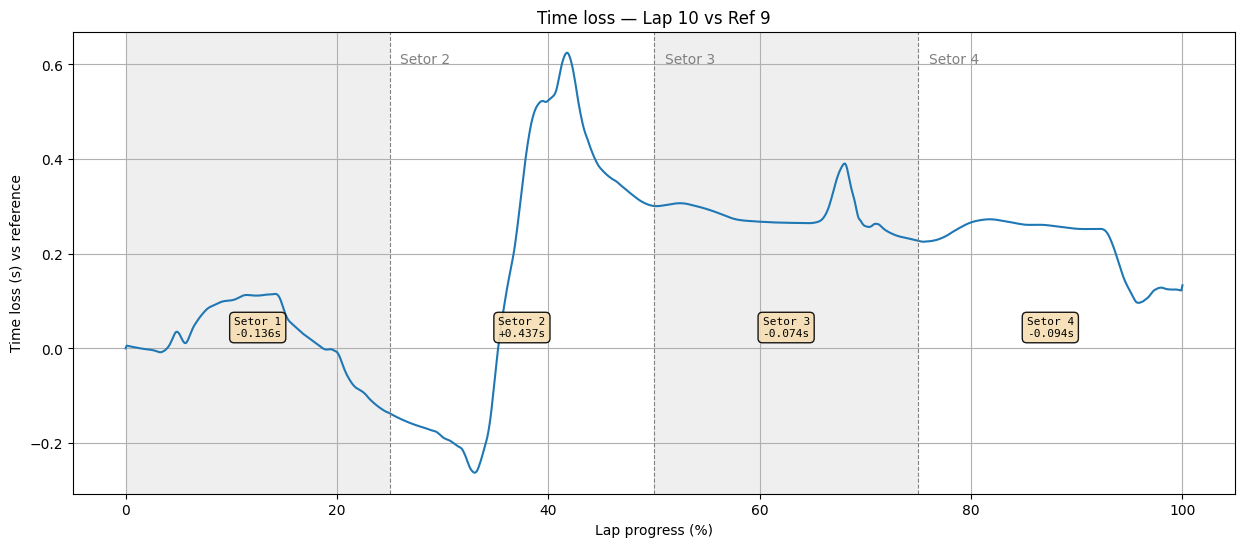

In [38]:
# --- 1. EXTRAIR OS LIMITES DOS SETORES ---

# De acordo com sua regra, dividimos a pista em 4 setores iguais.
num_setores = N_SECTORS

# Para 4 setores, os limites são em 0%, 25%, 50%, 75% e 100%.
# Criamos a lista de limites matematicamente.
sector_boundaries = [i / num_setores for i in range(num_setores + 1)]

print(f"Limites dos setores definidos em (%): {[round(b*100, 1) for b in sector_boundaries]}")

# --- 2. CRIAR FUNÇÃO AUXILIAR PARA DESENHAR OS SETORES ---

def add_sector_shading(ax, boundaries):
    """Aplica sombreamento e linhas verticais para cada setor em um gráfico."""
    colors = ['#E0E0E0', '#FFFFFF'] # Cinza claro e branco
    for i in range(len(boundaries) - 1):
        start_pos = boundaries[i] * 100
        end_pos = boundaries[i+1] * 100
        
        # Aplica o sombreamento de fundo
        ax.axvspan(start_pos, end_pos, facecolor=colors[i % 2], alpha=0.5, zorder=-100)
        
        # Adiciona uma linha vertical pontilhada no início de cada setor (exceto o primeiro)
        if i > 0:
            ax.axvline(x=start_pos, color='gray', linestyle='--', linewidth=0.8)
            # Adiciona o texto "Setor X"
            ax.text(start_pos + 1, ax.get_ylim()[1] * 0.9, f'Setor {i+1}', color='gray', ha='left')

sector_deltas = []
for i in range(N_SECTORS):
    start_boundary = sector_boundaries[i]
    end_boundary = sector_boundaries[i+1]
    
    start_idx = int(start_boundary * (BASE_GRID_LEN - 1))
    end_idx = int(end_boundary * (BASE_GRID_LEN - 1))
    
    time_at_sector_start = time_loss[start_idx] if i > 0 else 0.0
    time_at_sector_end = time_loss[end_idx]
    
    delta = time_at_sector_end - time_at_sector_start
    sector_deltas.append(delta)


# --- Bloco 2: Plotagem da Curva com Caixas de Texto Individuais ---

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(grid*100.0, time_loss)
ax.set_xlabel("Lap progress (%)")
ax.set_ylabel("Time loss (s) vs reference")
ax.set_title(f"Time loss — Lap {target_lap} vs Ref {ref_lap}")
ax.grid(True)

# Adicionamos o sombreamento dos setores como antes
add_sector_shading(ax, sector_boundaries)

# Propriedades da caixa de texto (será a mesma para todas)
props = dict(boxstyle='round,pad=0.4', facecolor='wheat', alpha=0.9)

# <<< SEÇÃO MODIFICADA: Loop para criar uma caixa por setor >>>
# Obtemos a altura máxima do gráfico para posicionar as caixas de texto
plot_top_y = ax.get_ylim()[1] 

for i, delta in enumerate(sector_deltas):
    # Posição X: no meio do setor atual
    start_pos_x = sector_boundaries[i] * 100
    end_pos_x = sector_boundaries[i+1] * 100
    mid_pos_x = (start_pos_x + end_pos_x) / 2
    
    # Posição Y: perto do topo do gráfico para consistência
    pos_y = plot_top_y * 0.10
    
    # Texto para a caixa
    text_per_sector = f"Setor {i+1}\n{delta:+.3f}s"
    
    # Adiciona a caixa de texto para o setor atual
    ax.text(mid_pos_x, pos_y, text_per_sector, 
            ha='center', va='top', # Alinha a caixa pelo centro e topo
            fontsize=8,
            bbox=props, 
            fontfamily='monospace')

plt.show()


## 10. Professional English coaching via local LLM (Ollama)

We construct a compact JSON with **per-sector deltas, uncertainties, conservative target gains**, and **signal summaries**.  
Then we call **Ollama** (`/api/chat`) to generate a pit-wall style coaching brief in English.

> Set `OLLAMA_MODEL` to any local model you have installed (e.g., `llama3.1:8b-instruct`, `qwen2.5:7b-instruct`, `phi3:medium-4k-instruct`, etc.).


In [23]:
import pandas as pd
import numpy as np
import json
import time
import requests
import sys

# --- SUAS VARIÁVEIS E FUNÇÕES (NÃO MODIFICADAS) ---

OLLAMA_HOST   = "http://localhost:11434"
OLLAMA_MODEL = "gemma3:12b"
TEMPERATURE   = 0.15
MAX_TOKENS   = 900
TOP_K_SECTORS = 10

CANDIDATE_SIGNAL_COLS = [
    "spe_mean","spe_max","spe_min","spe_delta",
    "thr_mean","thr_p95","thr_on_ratio",
    "bra_mean","bra_p95","bra_on_ratio",
    "rpm_mean","rpm_max","coa_ratio", "steer_std_dev", "thr_std_dev", "gear_at_apex"]


def ollama_chat(model: str, system_msg: str, user_msg: str,
                temperature: float = 0.15, max_tokens: int = 900, retries: int = 2) -> str:
    url = f"{OLLAMA_HOST}/api/chat"
    payload = {
        "model": model,
        "messages": [
            {"role": "system", "content": system_msg},
            {"role": "user",   "content": user_msg}
        ],
        "options": {"temperature": temperature, "num_predict": max_tokens},
        "stream": True
    }
    last_error = None
    for attempt in range(retries + 1):
        try:
            with requests.post(url, json=payload, stream=True, timeout=300) as response:
                response.raise_for_status()
                full_response = []
                print("\n=========== Coaching (LLM) ===========\n")
                print("Recebendo análise do coach em tempo real...")
                for line in response.iter_lines():
                    if line:
                        chunk = json.loads(line)
                        content = chunk.get("message", {}).get("content", "")
                        print(content, end='', flush=True)
                        full_response.append(content)
                print("\n\n--- Análise concluída ---")
                return "".join(full_response).strip()
        except Exception as e:
            last_error = e
            print(f"\n[Tentativa {attempt + 1}] Erro: {e}. Tentando novamente...", file=sys.stderr)
            time.sleep(1)
    raise RuntimeError(f"Ollama chat failed after {retries + 1} attempts: {last_error}")

# (As funções ollama_chat, CANDIDATE_SIGNAL_COLS, etc. devem estar definidas)
# ...

# ==============================================================================
# 1. FUNÇÕES AUXILIARES CONFIÁVEIS
# ==============================================================================

# <<< ESTA É A NOSSA FUNÇÃO CONFIÁVEL PARA CALCULAR TEMPOS DE SETOR >>>
def get_sector_times(lap_data: pd.DataFrame, n_sectors: int) -> pd.DataFrame:
    """Calcula o tempo gasto em cada setor para uma única volta, diretamente dos dados brutos."""
    sector_boundaries = np.linspace(0.0, 1.0, n_sectors + 1)
    sector_times = []
    for i in range(n_sectors):
        start_pct, end_pct = sector_boundaries[i], sector_boundaries[i+1]
        time_at_start = np.interp(start_pct, lap_data['LapDistPct'], lap_data['SessionTime'])
        time_at_end = np.interp(end_pct, lap_data['LapDistPct'], lap_data['SessionTime'])
        sector_times.append({"sector": i + 1, "true_time_s": time_at_end - time_at_start})
    return pd.DataFrame(sector_times)


# <<< NOVA FUNÇÃO PARA CONSTRUIR O PROMPT CORRETO >>>
def build_llm_comparison_prompt(ref_lap: int, target_lap: int, df, feat_df, n_sectors: int) -> tuple[str, str]:
    """
    Constrói um prompt de texto claro para o LLM, usando dados de tempo corretos e
    features de telemetria da feat_table.
    """
    # 1. Calcula os tempos de setor corretos usando a função confiável
    ref_times_tbl = get_sector_times(df[df['Lap'] == ref_lap], n_sectors)
    target_times_tbl = get_sector_times(df[df['Lap'] == target_lap], n_sectors)

    # 2. Compara os tempos para obter o delta_ms real
    time_comp_tbl = pd.merge(target_times_tbl, ref_times_tbl, on="sector", suffixes=('_tgt', '_ref'))
    time_comp_tbl['delta_ms'] = 1000.0 * (time_comp_tbl['true_time_s_tgt'] - time_comp_tbl['true_time_s_ref'])
    total_loss_ms = float(np.clip(time_comp_tbl["delta_ms"], 0, None).sum())
    
    # 3. Pega as features de telemetria da feat_table
    ref_feat_tbl = feat_df[feat_df['lap'] == ref_lap].set_index('sector')
    tgt_feat_tbl = feat_df[feat_df['lap'] == target_lap].set_index('sector')
    
    # 4. Constrói o prompt em texto, setor por setor
    prompt_lines = [
        f"Análise comparativa: Volta Alvo ({target_lap}) vs. Volta de Referência ({ref_lap}).",
        f"Perda de tempo total na volta alvo: {total_loss_ms:.0f} ms.",
        "Analise os dados setor a setor. Um delta_ms positivo significa que a volta alvo foi mais lenta.",
        "Para cada setor com perda de tempo, explique o porquê comparando os 'sinais' de telemetria e dê uma dica técnica e concreta.",
        
        # <<< NOVA SEÇÃO DE REGRAS DE FORMATAÇÃO >>>
        "\n--- REGRAS DE FORMATAÇÃO OBRIGATÓRIAS ---\n",
        "- Use markdown para formatação (ex: **títulos em negrito**).",
        "- **IMPORTANTE: Use quebras de linha (`\n`) para separar títulos, dicas e diferentes seções.**",
        "- A resposta deve ser clara, organizada em parágrafos e fácil de ler.",
        # <<< FIM DA NOVA SEÇÃO >>>

        "\n--- DADOS ---\n"
    ]

    # Itera apenas nos setores com perda de tempo
    for _, row in time_comp_tbl[time_comp_tbl['delta_ms'] > 0].sort_values("delta_ms", ascending=False).iterrows():
        s = int(row['sector'])
        line = f"**Setor {s}**\n"
        line += f"- Perda de Tempo (delta_ms): {row['delta_ms']:.0f} ms\n"
        
        # Adiciona features da volta alvo
        line += "- Telemetria da Volta Alvo:\n"
        for sig in CANDIDATE_SIGNAL_COLS:
            if sig in tgt_feat_tbl.columns:
                line += f"  - {sig}: {tgt_feat_tbl.loc[s, sig]:.2f}\n"
        
        # Adiciona features da volta de referência
        line += "- Telemetria da Volta de Referência:\n"
        for sig in CANDIDATE_SIGNAL_COLS:
            if sig in ref_feat_tbl.columns:
                line += f"  - {sig}: {ref_feat_tbl.loc[s, sig]:.2f}\n"
        
        prompt_lines.append(line)

    user_msg = "\n".join(prompt_lines)
    system_msg = (
        "Você é um engenheiro de corridas profissional do iRacing. Seja conciso, técnico e direto. "
        "Sua análise deve ser baseada estritamente nos dados de comparação fornecidos. "
        "Foque em dar conselhos práticos sobre a técnica de pilotagem (pontos de frenagem, aplicação de acelerador, velocidade de ápice)."
    )
    return system_msg, user_msg

# ==============================================================================
# 2. FUNÇÃO PRINCIPAL MODIFICADA
# ==============================================================================

def generate_pro_coaching_english(ref_lap: int, target_lap: int, df, feat_df, n_sectors: int,
                                  model: str = OLLAMA_MODEL,
                                  temperature: float = TEMPERATURE,
                                  max_tokens: int = MAX_TOKENS) -> str:
    """
    Gera coaching do LLM usando o novo e robusto construtor de prompt.
    """
    # Constrói o prompt de texto claro e com dados corretos
    sys_msg, usr_msg = build_llm_comparison_prompt(ref_lap, target_lap, df, feat_df, n_sectors)
    
    # Descomente a linha abaixo se quiser ver o prompt exato que está sendo enviado para a IA
    # print(usr_msg)
    
    # Chama o LLM com o novo prompt
    return ollama_chat(model, sys_msg, usr_msg, temperature=temperature, max_tokens=max_tokens)


# ==============================================================================
# 3. BLOCO DE EXECUÇÃO
# ==============================================================================

# (Assumindo que `ref_lap` e `target_lap` foram definidos na célula anterior)
print(f"Generating English coaching for lap {target_lap} vs ref {ref_lap} with {OLLAMA_MODEL}...")

try:
    # Chama a função atualizada, passando os DataFrames e variáveis necessários
    generate_pro_coaching_english(ref_lap, target_lap, df, feat_table, N_SECTORS)
except Exception as e:
    print(f"[LLM step skipped] {e}", file=sys.stderr)

Generating English coaching for lap 6 vs ref 9 with gemma3:12b...

=========== Coaching (LLM) ===========

Recebendo análise do coach em tempo real...
**Análise Geral**

A volta alvo está perdendo tempo significativamente nos setores 1, 2 e 3. A perda no setor 4 é mínima, indicando que a técnica final é relativamente boa. A análise se concentrará em corrigir as deficiências nos setores onde a perda de tempo é mais acentuada.

---

**Setor 1: Perda de Tempo (881 ms)**

*   **Problema:** A velocidade média (spe_mean) é inferior em 4.56 m/s. O throttle médio (thr_mean) é 8.06 menor.
*   **Telemetria:** A velocidade média mais baixa indica uma frenagem tardia ou uma saída de curva mais lenta. O throttle médio mais baixo sugere uma aplicação de acelerador conservadora.
*   **Dica Técnica:** Aproxime o ponto de frenagem. A velocidade de ápice é similar, então a perda de tempo está na entrada da curva. Aumente gradualmente a aplicação do acelerador na saída, buscando o RPM máximo do motor.

-

Limites dos setores definidos em (%): [0.0, 25.0, 50.0, 75.0, 100.0]


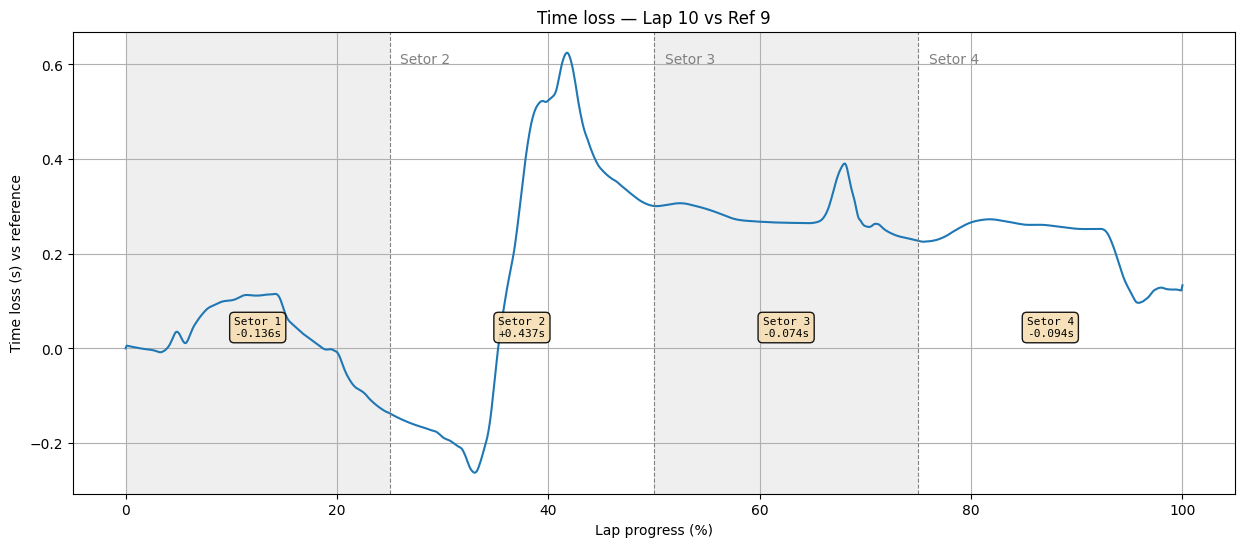


## 11. Appendix — Tips & troubleshooting

- If your **.ibt** is large, reading may be slow. Save a CSV once and reuse it.
- **Reference robustness:** tweak `TOPK_PERCENT`. Medians reduce outlier sensitivity.
- **Pace filter:** `PACE_THRESHOLD_MS` trims poor laps; loosen/tighten per use case.
- **Model choice:** LightGBM if available; otherwise GradientBoosting (works offline).
- **Uncertainty (±σ):** derived from fold residuals per sector; more data → better σ.
- **LLM:** set `OLLAMA_MODEL` to a locally installed model. The JSON context keeps prompts short but information-dense.


# 🏎️ Lap Time Analysis: Direct Comparison vs. AI Explanation

When analyzing driver performance in racing telemetry, there are **two complementary layers**:

---

## ⚡ 1. Direct Delta Calculation (No AI)

The simplest way to measure performance is by comparing each sector of the driver’s lap against a **reference lap**.  

- Each lap is divided into equal **sectors** (e.g., 10 segments from 0% to 100% of lap distance).  
- For each sector, we compute the **time spent**.  
- By subtracting the driver’s sector time from the reference, we obtain the **time loss or gain**:  

\[
\Delta t_{sector} = t_{sector}^{driver} - t_{sector}^{reference}
\]

Example:

- **Sector 1:** +0.7s slower  
- **Sector 6:** equal to reference  
- **Sector 9:** +0.1s slower  

This provides a clear **“where”** the driver lost time.

---

## 🤖 2. Explaining the *Why* with AI or Heuristics

Knowing *where* the driver lost time is not enough — effective coaching requires understanding *why*.  
This is achieved by analyzing **sector-level statistics** (engineered features) such as:

- **Speed**
  - Average, minimum, maximum, delta (exit – entry)
- **Throttle**
  - Mean, percentiles (p95, p10), ratio of time on throttle
- **Brake**
  - Mean, near-maximum, ratio of time on brakes
- **RPM**
  - Mean, maximum

### 🔹 A) Rule-based Heuristics  
We can design simple coaching rules:  
- Low throttle ratio → *“Late on throttle; accelerate earlier.”*  
- High brake ratio + low speed → *“Braked too much; lost exit speed.”*  
- Very high RPM max → *“Shift earlier to avoid hitting the limiter.”*

### 🔹 B) Machine Learning Models  
Alternatively, a **regression model** (e.g., LightGBM or RandomForest) can be trained to predict **sector time losses** from these features.  
The model learns patterns such as:  
- Excessive braking correlates with sector time loss.  
- Lower average throttle correlates with slower sector times.  

This enables **generalization**: the model can estimate potential losses or gains even without a direct reference lap comparison.

---

## 🏁 3. Coaching Integration with LLM

Finally, we combine both layers:  
- **Delta times (raw data)** → quantify *how much* time was lost in each sector.  
- **Feature-based analysis (AI/heuristics)** → explain *why* the time was lost.  
- **Language Model (LLM, e.g., Ollama)** → translate this into **natural language coaching** for the driver:

> *“Sector 1: +0.7s slower. You braked too heavily (brake_on_ratio = 30%), which reduced your average speed (120 km/h vs ref 125). Focus on braking shorter and earlier throttle application to improve exit speed.”*

---

✅ In summary:  
- **Direct deltas = where.**  
- **Features + AI/heuristics = why.**  
- **LLM = actionable coaching advice.**